In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/cleaned_online_retail_II.csv")

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(417534, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417534 entries, 0 to 417533
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      417534 non-null  object 
 1   StockCode    417534 non-null  object 
 2   Description  417534 non-null  object 
 3   Quantity     417534 non-null  int64  
 4   InvoiceDate  417534 non-null  object 
 5   Price        417534 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      417534 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 25.5+ MB


In [6]:
df=df.rename(columns={
    "Customer ID":"customer_id",
    "InvoiceDate":"transaction_date"
})


In [7]:
from datetime import timedelta
df['transaction_date']=pd.to_datetime(df['transaction_date'])

In [8]:
df.dropna()

,Invoice,StockCode,Description,Quantity,transaction_date,Price,customer_id,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
417529,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
417530,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
417531,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
417532,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


In [9]:
df['transaction_amount']=df['Price']*df['Quantity']

In [10]:
df=df[df['transaction_amount']>0]

In [11]:
df=df[['customer_id','transaction_date','transaction_amount']]

In [12]:

df.shape

(407664, 3)

In [13]:
#predict for next 6 months
prediction_window_days = 180

max_date = df['transaction_date'].max()
cutoff_date = max_date - timedelta(days=prediction_window_days)

past_data = df[df['transaction_date'] <= cutoff_date]
future_data = df[df['transaction_date'] > cutoff_date]



In [14]:
print(max_date)
print(cutoff_date)

2010-12-09 20:01:00
2010-06-12 20:01:00


In [15]:
reference_date = cutoff_date

customer_features = past_data.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (reference_date - x.max()).days),
    frequency=('transaction_amount', 'count'),
    avg_spend=('transaction_amount', 'mean'),
    tenure=('transaction_date', lambda x: (x.max() - x.min()).days)
).reset_index()



In [16]:
future_revenue = (
    future_data
    .groupby('customer_id')['transaction_amount']
    .sum()
    .reset_index()
    .rename(columns={'transaction_amount': 'future_revenue'})
)
training_data = customer_features.merge(
    future_revenue,
    on='customer_id',
    how='inner'
)


In [17]:
training_data.head()

,customer_id,recency,frequency,avg_spend,tenure,future_revenue
0,12346.0,102,14,16.467857,78,142.31
1,12349.0,25,47,26.989787,18,1402.62
2,12358.0,5,35,48.512286,181,1021.08
3,12359.0,81,66,23.064091,107,1041.13
4,12360.0,18,45,17.334222,92,810.79


In [18]:
X=training_data[['recency', 'frequency', 'avg_spend', 'tenure']]

In [19]:
Y=training_data['future_revenue']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,shuffle=True)

In [22]:
model=RandomForestRegressor(
    n_estimators=200,
)
model.fit(X_train,Y_train)

RandomForestRegressor(n_estimators=200)

In [23]:
y_pred=model.predict(X_test)

In [24]:
print("Mean Absolute error",mean_absolute_error(y_pred,Y_test))

Mean Absolute error 1438.9094057750003


In [25]:
print(r2_score(y_pred,Y_test))

-1.7167153013923762


In [26]:
final_reference_date = df['transaction_date'].max() + timedelta(days=1)

all_customers = df.groupby('customer_id').agg(
    recency=('transaction_date', lambda x: (final_reference_date - x.max()).days),
    frequency=('transaction_amount', 'count'),
    avg_spend=('transaction_amount', 'mean'),
    tenure=('transaction_date', lambda x: (x.max() - x.min()).days)
).reset_index()

all_customers['predicted_clv'] = model.predict(
    all_customers[['recency', 'frequency', 'avg_spend', 'tenure']]
)
final_output = all_customers.sort_values(
    by='predicted_clv',
    ascending=False
)

final_output.head(10)


,customer_id,recency,frequency,avg_spend,tenure,predicted_clv
1637,14646.0,10,1773,140.099549,362,99476.77765
939,13694.0,9,957,137.349206,361,69487.50010
2133,15311.0,1,2055,27.252195,373,67777.60460
1269,14156.0,7,2648,74.232153,366,67177.27630
1840,14911.0,1,5570,27.315542,373,66989.94470
3744,17511.0,3,948,89.178449,369,63427.72440
4183,18102.0,1,627,556.880941,373,57797.39275
510,13093.0,9,891,52.874501,362,55077.96900
1378,14298.0,11,1227,32.328598,352,53464.21570
506,13089.0,4,1544,37.507791,368,51507.49685


In [27]:
#top 10 customers
top_10=final_output.head(10)

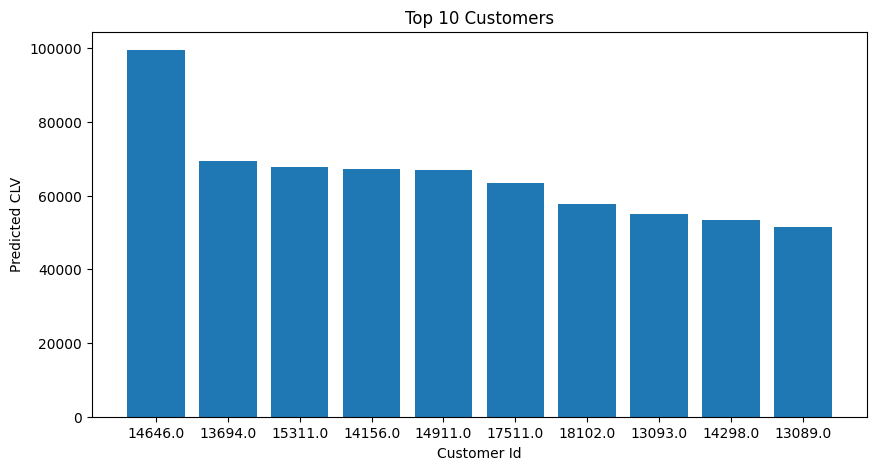

In [28]:
from matplotlib.container import BarContainer
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(top_10['customer_id'].astype(str),top_10['predicted_clv'])
plt.xlabel("Customer Id")
plt.ylabel("Predicted CLV")
plt.title("Top 10 Customers")

plt.show()

In [29]:
pip install joblib


In [30]:
import joblib

joblib.dump(model, "clv_model.pkl")


['clv_model.pkl']